# Task 1: Credit Scoring Model — CodeAlpha ML Internship

**Objective:** Predict an individual's creditworthiness (Poor / Standard / Good) using financial and behavioral data.

**Dataset:** [Credit Score Classification](https://www.kaggle.com/datasets/parisrohan/credit-score-classification) — 100,000 records, 28 features including income, debt, payment history, and credit behavior.

**Approach:** Data cleaning → feature encoding → train Logistic Regression, Decision Tree, and Random Forest classifiers → compare using Precision, Recall, F1-Score, and ROC-AUC.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

sns.set_style("whitegrid")

## 1. Load the Dataset

In [3]:
df = pd.read_csv("dataset/train.csv", low_memory=False)
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


## 2. Data Cleaning
The raw dataset has several issues typical of real-world financial data: numeric columns stored as text with stray underscores, invalid negative ages, and placeholder junk values (e.g. `"_"` in `Credit_Mix`). This section drops identifier columns (not predictive), fixes data types, and parses the `Credit_History_Age` text field into a numeric value (months).

In [4]:
df = df.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN'])

def clean_numeric(col):
    return pd.to_numeric(df[col].astype(str).str.replace('_', '', regex=False).str.strip(), errors='coerce')

for col in ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment',
            'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly',
            'Monthly_Balance']:
    if col in df.columns:
        df[col] = clean_numeric(col)

df.loc[(df['Age'] < 0) | (df['Age'] > 100), 'Age'] = np.nan

df['Credit_Mix'] = df['Credit_Mix'].replace('_', np.nan)

df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', np.nan)

def parse_credit_history(val):
    if pd.isna(val):
        return np.nan
    try:
        years = int(val.split(' Years')[0])
        months = int(val.split('and ')[1].split(' Months')[0])
        return years * 12 + months
    except:
        return np.nan

df['Credit_History_Age'] = df['Credit_History_Age'].apply(parse_credit_history)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Month                     100000 non-null  str    
 1   Age                       97224 non-null   float64
 2   Occupation                100000 non-null  str    
 3   Annual_Income             100000 non-null  float64
 4   Monthly_Inhand_Salary     84998 non-null   float64
 5   Num_Bank_Accounts         100000 non-null  int64  
 6   Num_Credit_Card           100000 non-null  int64  
 7   Interest_Rate             100000 non-null  int64  
 8   Num_of_Loan               100000 non-null  int64  
 9   Type_of_Loan              88592 non-null   str    
 10  Delay_from_due_date       100000 non-null  int64  
 11  Num_of_Delayed_Payment    92998 non-null   float64
 12  Changed_Credit_Limit      97909 non-null   float64
 13  Num_Credit_Inquiries      98035 non-null   float64
 14  

## 3. Handling Missing Values & Encoding
Numeric missing values are filled with the column median, categorical ones with the mode. Categorical features are label-encoded so models can use them, and the target `Credit_Score` is mapped to 0/1/2 (Poor/Standard/Good).

In [5]:
# Fill numeric missing values with median
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include=['str', 'object']).columns.drop('Credit_Score')
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Drop Type_of_Loan for now - it's a messy multi-value text field, too complex for a first model
df = df.drop(columns=['Type_of_Loan'])

# Encode categorical columns
le = LabelEncoder()
for col in ['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']:
    df[col] = le.fit_transform(df[col])

# Encode target
df['Credit_Score'] = df['Credit_Score'].map({'Poor': 0, 'Standard': 1, 'Good': 2})

df.isnull().sum().sum()  # should print 0

np.int64(0)

## 4. Train/Test Split & Feature Scaling
An 80/20 stratified split preserves class balance across train and test sets. Features are standardized (zero mean, unit variance) for models sensitive to feature scale.

In [6]:
X = df.drop(columns=['Credit_Score'])
y = df['Credit_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(80000, 22) (20000, 22)


## 5. Model Training & Comparison
We train three classifiers — Logistic Regression, Decision Tree, and Random Forest — and compare their performance on the held-out test set.

In [7]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    
    results[name] = preds
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    print(classification_report(y_test, preds, target_names=['Poor', 'Standard', 'Good']))


Logistic Regression
              precision    recall  f1-score   support

        Poor       0.63      0.43      0.51      5799
    Standard       0.62      0.78      0.69     10635
        Good       0.53      0.40      0.46      3566

    accuracy                           0.61     20000
   macro avg       0.59      0.54      0.55     20000
weighted avg       0.61      0.61      0.59     20000


Decision Tree
              precision    recall  f1-score   support

        Poor       0.66      0.66      0.66      5799
    Standard       0.72      0.72      0.72     10635
        Good       0.58      0.57      0.58      3566

    accuracy                           0.68     20000
   macro avg       0.65      0.65      0.65     20000
weighted avg       0.68      0.68      0.68     20000


Random Forest
              precision    recall  f1-score   support

        Poor       0.78      0.80      0.79      5799
    Standard       0.80      0.81      0.80     10635
        Good       0.73 

## 6. Confusion Matrix (Random Forest)
Random Forest performed best across all metrics, so we examine it further to see where it gets confused between the three credit score classes.

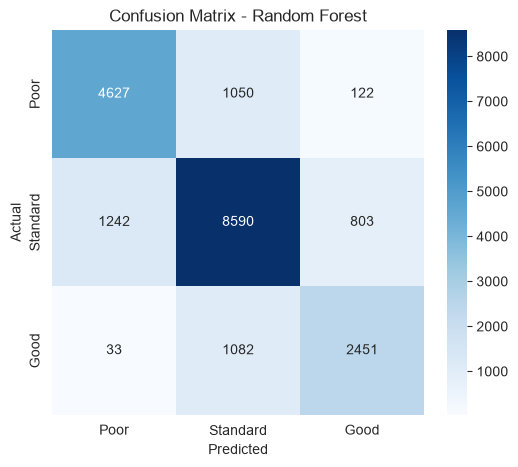

In [8]:
rf_model = models['Random Forest']
rf_preds = results['Random Forest']

cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Poor','Standard','Good'],
            yticklabels=['Poor','Standard','Good'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.savefig('results/confusion_matrix.png', bbox_inches='tight')
plt.show()

## 7. ROC-AUC Score & Feature Importance
ROC-AUC measures how well the model separates the three classes across all decision thresholds. Feature importance shows which financial factors most influenced the model's predictions.

ROC-AUC Score (One-vs-Rest): 0.9074


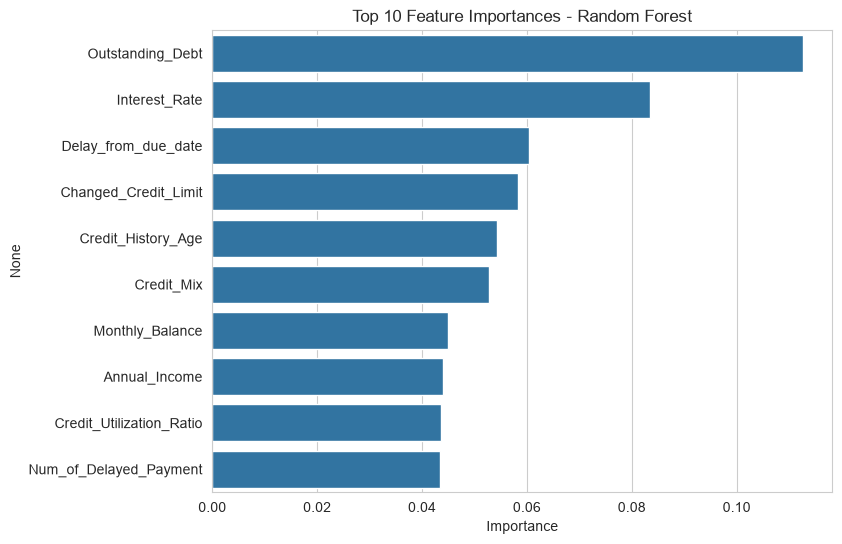

In [9]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0,1,2])
rf_probs = rf_model.predict_proba(X_test)
roc_auc = roc_auc_score(y_test_bin, rf_probs, multi_class='ovr')
print(f"ROC-AUC Score (One-vs-Rest): {roc_auc:.4f}")

importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(x=importances.head(10), y=importances.head(10).index)
plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.savefig('results/feature_importance.png', bbox_inches='tight')
plt.show()

In [10]:
import joblib
import os

os.makedirs('models', exist_ok=True)
joblib.dump(rf_model, 'models/credit_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
print("Model saved.")

Model saved.


## 8. Summary

Three classifiers were trained to predict credit score category (Poor / Standard / Good):

| Model | Accuracy | F1 (weighted) |
|---|---|---|
| Logistic Regression | 61% | 0.59 |
| Decision Tree | 68% | 0.68 |
| **Random Forest** | **78%** | **0.78** |

**Random Forest** performed best and was selected as the final model, achieving a **ROC-AUC of 0.9074**. The confusion matrix shows the model rarely confuses the two extreme classes (Poor vs. Good), with most errors occurring between the adjacent Standard/Good classes — an intuitive result. Feature importance analysis shows **Outstanding_Debt**, **Interest_Rate**, and **Delay_from_due_date** are the strongest predictors, consistent with real-world credit risk factors.